# CM52060 — Bayesian Data Science: Assessment Part B
## Deployable Model — `deployable.ipynb`

This notebook implements the specimen deployable prediction model (Section 4.4).

It loads the pre-trained **Enhanced Hierarchical Bayesian Degradation Model** from
saved posterior samples. **No training is performed here.**

### Required files
```
deployable.ipynb
model_data/
    samps_enh_ui.npy   — posterior samples of u_i,  shape (S, 75)
    samps_enh_vi.npy   — posterior samples of v_i,  shape (S, 75)
    samps_enh_w.npy    — posterior samples of w,    shape (S, 5)
    X_feats.npy        — component feature matrix,  shape (75, 5)
bml-component-data.csv — original dataset (for examples only)
```


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## `DegradationModel` — Pre-trained Model Object

Loads saved posterior samples from disk. No training is performed.


In [2]:
class DegradationModel:

    def __init__(self, model_dir='model_data'):
        self.u_i = np.load(f'{model_dir}/samps_enh_ui.npy')
        self.v_i = np.load(f'{model_dir}/samps_enh_vi.npy')
        self.w   = np.load(f'{model_dir}/samps_enh_w.npy')
        self.X   = np.load(f'{model_dir}/X_feats.npy')
        self.S   = self.u_i.shape[0]
        self.N   = self.u_i.shape[1]
        print(f'DegradationModel loaded: {self.S} posterior samples, '
              f'{self.N} components.')

## `predict` — Prediction Function

### Model

$$f_i(t) = u_i \exp\!\left(-\frac{\left(v_i + \sum_{j=1}^{5} w_j x_{ji}\right) t}{100}\right)$$

Returns:
- `pred_mean` — posterior mean of $f_i(t)$
- `pred_std`  — posterior std of $f_i(t)$ (function uncertainty only; $\sigma_y$ excluded per spec)

Accepts scalar or vector `day`. Fully vectorised — no explicit loops.
Self-contained — references only `model_obj`.


In [3]:
def predict(index, day, model_obj):
    day = np.atleast_1d(np.asarray(day, dtype=np.float64))

    u   = model_obj.u_i[:, index]
    v   = model_obj.v_i[:, index]
    w   = model_obj.w
    x_i = model_obj.X[index]

    eff_v = v + w @ x_i


    f = u[:, None] * np.exp(-eff_v[:, None] * day[None, :] / 100.0)

    pred_mean = f.mean(axis=0)
    pred_std  = f.std(axis=0)

    if pred_mean.size == 1:
        return float(pred_mean[0]), float(pred_std[0])
    return pred_mean, pred_std

## Load the Pre-trained Model

In [4]:
model_obj = DegradationModel(model_dir='model_data')

DegradationModel loaded: 8000 posterior samples, 75 components.


## Illustrative Examples


### Example 1 — Scalar `day`: single prediction

In [5]:
index = 0
day   = 30.0

pred_mean, pred_std = predict(index, day, model_obj)

print(f'Component index : {index}')
print(f'Prediction day  : {day} days')
print(f'Predicted mean  : {pred_mean:.2f}%')
print(f'Predicted std   : {pred_std:.2f}%')
print(f'95% interval    : [{pred_mean - 1.96*pred_std:.2f}%, {pred_mean + 1.96*pred_std:.2f}%]')

Component index : 0
Prediction day  : 30.0 days
Predicted mean  : 42.07%
Predicted std   : 1.07%
95% interval    : [39.96%, 44.18%]


### Example 2 — Vector `day`: full degradation curve

Output shapes: mean=(300,), std=(300,)


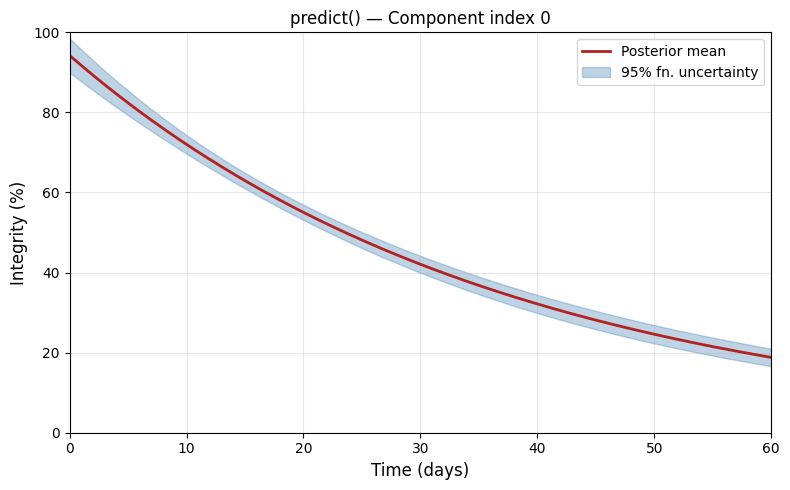

In [6]:
index    = 0
days_vec = np.linspace(0, 60, 300)

pred_mean, pred_std = predict(index, days_vec, model_obj)

print(f'Output shapes: mean={pred_mean.shape}, std={pred_std.shape}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(days_vec, pred_mean, color='firebrick', lw=2, label='Posterior mean')
ax.fill_between(days_vec,
                pred_mean - 1.96 * pred_std,
                pred_mean + 1.96 * pred_std,
                alpha=0.35, color='steelblue', label='95% fn. uncertainty')
ax.set_xlim(0, 60); ax.set_ylim(0, 100)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Integrity (%)', fontsize=12)
ax.set_title(f'predict() — Component index {index}', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Example 3 — Four components with data overlaid

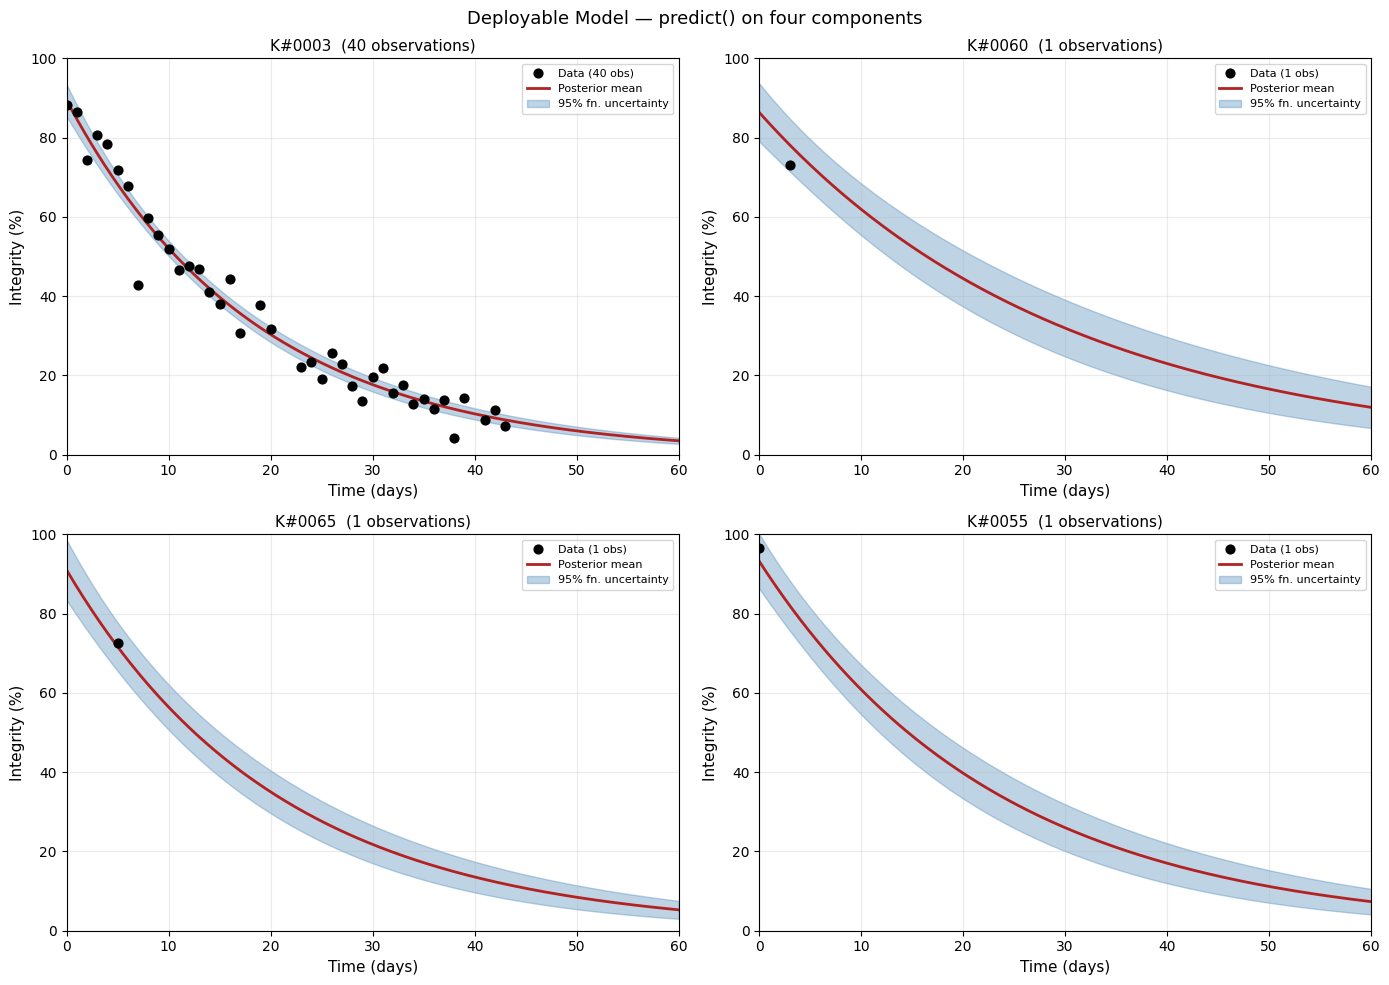

In [7]:
data = pd.read_csv('bml-component-data.csv')

components = [3, 60, 65, 55]
days_vec   = np.linspace(0, 60, 300)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, ci in zip(axes.flat, components):
    cdf     = data[data['index'] == ci]
    comp_id = cdf['ID'].iloc[0]
    n_obs   = len(cdf)

    pred_mean, pred_std = predict(ci, days_vec, model_obj)

    ax.scatter(cdf['day'], cdf['integrity'],
               color='black', s=40, zorder=5, label=f'Data ({n_obs} obs)')
    ax.plot(days_vec, pred_mean, color='firebrick', lw=2, label='Posterior mean')
    ax.fill_between(days_vec,
                    pred_mean - 1.96 * pred_std,
                    pred_mean + 1.96 * pred_std,
                    alpha=0.35, color='steelblue', label='95% fn. uncertainty')
    ax.set_xlim(0, 60); ax.set_ylim(0, 100)
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel('Integrity (%)', fontsize=11)
    ax.set_title(f'{comp_id}  ({n_obs} observations)', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.suptitle('Deployable Model — predict() on four components', fontsize=13)
plt.tight_layout()
plt.show()

### Example 4 — Blind test: P(integrity ≤ 30% at t=30)

In [8]:
T_PRED    = 30.0
THRESHOLD = 30.0

predictions = []
for ci in range(50, 75):
    comp_id = data[data['index'] == ci]['ID'].iloc[0]
    u     = model_obj.u_i[:, ci]
    v     = model_obj.v_i[:, ci]
    eff_v = v + model_obj.w @ model_obj.X[ci]
    f30   = u * np.exp(-eff_v * T_PRED / 100.0)
    prob  = float(np.mean(f30 <= THRESHOLD))
    predictions.append({'ID': comp_id, 'index': ci, 'probability': prob})

pred_df = pd.DataFrame(predictions)
print('P(integrity ≤ 30% at t=30) for test components:')
print(pred_df.to_string(index=False))

P(integrity ≤ 30% at t=30) for test components:
    ID  index  probability
K#0050     50     0.107500
K#0051     51     1.000000
K#0052     52     1.000000
K#0053     53     0.422000
K#0054     54     0.001875
K#0055     55     0.904125
K#0056     56     0.999750
K#0057     57     0.000000
K#0058     58     1.000000
K#0059     59     0.613875
K#0060     60     0.298875
K#0061     61     0.000625
K#0062     62     0.026875
K#0063     63     0.000500
K#0064     64     0.000000
K#0065     65     0.998375
K#0066     66     1.000000
K#0067     67     1.000000
K#0068     68     0.023125
K#0069     69     0.999875
K#0070     70     0.997625
K#0071     71     0.936000
K#0072     72     0.048375
K#0073     73     0.981250
K#0074     74     0.000125
